In [29]:
## Cell 1
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Loading raw dataset...")
file_path = '../raw_data/export_CAN_2023_2018.csv'
df_raw = pd.read_csv(file_path, low_memory=False)

print(f"Raw data loaded: {len(df_raw):,} rows.")

# 1. Create the binary target variable correctly
# NaN/Empty = Awarded (1) | Text/Reason = Not Awarded (0)
df_raw['target'] = df_raw['INFO_ON_NON_AWARD'].isna().astype(int)

# 2. Drop duplicates using the official TED identifiers to fix data leakage
print("\nRemoving duplicates using official TED identifiers...")
# We use ID_NOTICE_CAN (the general procedure ID) and ID_AWARD (the specific contract ID)
# We also include ID_LOT (if it exists) to ensure we don't accidentally drop valid, separate lots from the same notice.
subset_ids = []
if 'ID_NOTICE_CAN' in df_raw.columns:
    subset_ids.append('ID_NOTICE_CAN')
if 'ID_AWARD' in df_raw.columns:
    subset_ids.append('ID_AWARD')
if 'ID_LOT' in df_raw.columns:
    subset_ids.append('ID_LOT')
    
df_raw = df_raw.drop_duplicates(subset=subset_ids)
print(f"Data after official deduplication: {len(df_raw):,} rows.")

# 3. Separate into majority and minority classes
df_awarded = df_raw[df_raw['target'] == 1]
df_not_awarded = df_raw[df_raw['target'] == 0]

print(f"\nDistribution after official deduplication:")
print(f"  Awarded:     {len(df_awarded):,}")
print(f"  Not Awarded: {len(df_not_awarded):,}")

# 4. Determine the size of the minority class
minority_size = min(len(df_awarded), len(df_not_awarded))

# 5. Downsample the majority class to match the minority size
if len(df_awarded) > len(df_not_awarded):
    df_awarded_sampled = df_awarded.sample(n=minority_size, random_state=42)
    df_balanced = pd.concat([df_awarded_sampled, df_not_awarded])
else:
    df_not_awarded_sampled = df_not_awarded.sample(n=minority_size, random_state=42)
    df_balanced = pd.concat([df_awarded, df_not_awarded_sampled])

# 6. Shuffle the dataset and reset the index
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ Officially leak-free, balanced dataset created successfully!")
print(f"Total rows: {len(df_balanced):,}")
print("\nNew Target Distribution:")
print((df_balanced['target'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

Loading raw dataset...
Raw data loaded: 6,198,063 rows.

Removing duplicates using official TED identifiers...
Data after official deduplication: 6,193,849 rows.

Distribution after official deduplication:
  Awarded:     5,208,760
  Not Awarded: 985,089

✅ Officially leak-free, balanced dataset created successfully!
Total rows: 1,970,178

New Target Distribution:
target
1    50.0%
0    50.0%
Name: proportion, dtype: str


In [31]:
## Cell 2

import gc

print("Isolating features and optimizing data types...")

# 14 Clean Features (Leakage removed & deduplicated)
FEATURES = [
    'B_MULTIPLE_CAE', 'B_EU_FUNDS', 'LOTS_NUMBER', 'TOP_TYPE', 
    'YEAR', 'ISO_COUNTRY_CODE', 'TYPE_OF_CONTRACT', 'B_GPA', 
    'B_FRA_AGREEMENT', 'CRIT_PRICE_WEIGHT', 'CRIT_CODE', 
    'B_ACCELERATED', 'CAE_TYPE', 'MAIN_ACTIVITY'
]

CAT_FEATURES = ['TOP_TYPE', 'ISO_COUNTRY_CODE', 'TYPE_OF_CONTRACT', 'CAE_TYPE', 'MAIN_ACTIVITY']
BINARY_FEATURES = ['B_MULTIPLE_CAE', 'B_EU_FUNDS', 'B_GPA', 'B_FRA_AGREEMENT', 'B_ACCELERATED']
NUMERIC_FEATURES = ['CRIT_PRICE_WEIGHT', 'LOTS_NUMBER', 'YEAR']

# 1. Create the clean model dataframe
df_model = df_balanced[FEATURES + ['target']].copy()

# 2. Format Nominal Categoricals -> Native XGBoost handling
for col in CAT_FEATURES:
    df_model[col] = df_model[col].fillna('missing').astype('category')
    
# 3. Format Binary flags -> 1/0
for col in BINARY_FEATURES:
    df_model[col] = df_model[col].map({'Y': 1, 'N': 0}).fillna(0).astype(int)
    
# 4. Format CRIT_CODE: L vs M -> 0/1
df_model['CRIT_CODE'] = df_model['CRIT_CODE'].map({'L': 0, 'M': 1}).fillna(0).astype(int)

# 5. Format Numeric coercing
for col in NUMERIC_FEATURES:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce').fillna(0)

print(f"Matrix ready: {len(df_model):,} rows, {df_model.shape[1]} columns.")
print("\nData Types Summary:")
print(df_model.dtypes.value_counts())

# 6. Memory Cleanup: Delete the massive raw data variables
del df_raw
del df_balanced
del df_awarded
del df_not_awarded
gc.collect()

print("\n✅ Formatting complete. Raw data cleared from RAM.")

Isolating features and optimizing data types...
Matrix ready: 1,970,178 rows, 15 columns.

Data Types Summary:
int64       8
float64     2
category    1
category    1
category    1
category    1
category    1
Name: count, dtype: int64

✅ Formatting complete. Raw data cleared from RAM.


In [32]:
## Cell 3

from sklearn.model_selection import train_test_split

print("Splitting data into Train, Validation, and Test sets...")

X = df_model[FEATURES]
y = df_model['target']

# 1. First split: 80% Train, 20% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Second split: 50% of Temp to Validation, 50% of Temp to Test (Yielding 10% of total each)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("\n=== Data Split Summary ===")
print(f"Training Set:   {len(X_train):,} rows ({len(X_train)/len(df_model)*100:.0f}%)")
print(f"Validation Set: {len(X_valid):,} rows ({len(X_valid)/len(df_model)*100:.0f}%)")
print(f"Test Set:       {len(X_test):,} rows ({len(X_test)/len(df_model)*100:.0f}%)")

# Verify stratification worked properly
print(f"\nTrain Target Mean: {y_train.mean():.4f}")
print(f"Valid Target Mean: {y_valid.mean():.4f}")
print(f"Test Target Mean:  {y_test.mean():.4f}")

Splitting data into Train, Validation, and Test sets...

=== Data Split Summary ===
Training Set:   1,576,142 rows (80%)
Validation Set: 197,018 rows (10%)
Test Set:       197,018 rows (10%)

Train Target Mean: 0.5000
Valid Target Mean: 0.5000
Test Target Mean:  0.5000


In [34]:
## Cell 4

import optuna
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import gc

print("Setting up Optuna hyperparameter tuning...")

def objective(trial):
    # 1. Define hyperparameter search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 3.0),
        
        # Mandatory fixed parameters for Native Categoricals
        'tree_method': 'hist',
        'enable_categorical': True,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss',
        'early_stopping_rounds': 30
    }
    
    # 2. Initialize Model
    model = XGBClassifier(**params)
    
    # 3. Train with Early Stopping on the Validation Set
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False # Keep output clean
    )
    
    # 4. Predict and Evaluate on Validation Set
    y_valid_prob = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_prob)
    
    # Clean up memory per trial
    del model
    del y_valid_prob
    gc.collect()
    
    return auc

# Create and run the study
study = optuna.create_study(direction='maximize', study_name="XGB_Native_Cat_Tuning_LeakFree")
print("Starting optimization... (This may take some time depending on your CPU/GPU)")

# Set n_trials to 15 (increase to 30 or 50 if you want an even better model and have the time!)
study.optimize(objective, n_trials=50)

print("\n=== OPTUNA OPTIMIZATION FINISHED ===")
print(f"Best ROC-AUC Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-04-29 08:34:04,309] A new study created in memory with name: XGB_Native_Cat_Tuning_LeakFree


Setting up Optuna hyperparameter tuning...
Starting optimization... (This may take some time depending on your CPU/GPU)


[I 2026-04-29 08:34:09,432] Trial 0 finished with value: 0.7461003260262133 and parameters: {'n_estimators': 313, 'max_depth': 6, 'learning_rate': 0.023592518722509507, 'subsample': 0.9339769467033692, 'colsample_bytree': 0.6414131964235903, 'min_child_weight': 2, 'gamma': 0.2597360502101295, 'reg_alpha': 0.6300139483850278, 'reg_lambda': 1.1312101310976028}. Best is trial 0 with value: 0.7461003260262133.
[I 2026-04-29 08:34:18,995] Trial 1 finished with value: 0.7783651945644007 and parameters: {'n_estimators': 652, 'max_depth': 6, 'learning_rate': 0.13188321176394893, 'subsample': 0.7669599973896575, 'colsample_bytree': 0.546758637771498, 'min_child_weight': 4, 'gamma': 0.02687078406937371, 'reg_alpha': 1.693112870890003, 'reg_lambda': 0.6478878596665576}. Best is trial 1 with value: 0.7783651945644007.
[I 2026-04-29 08:34:29,714] Trial 2 finished with value: 0.7858728252029392 and parameters: {'n_estimators': 595, 'max_depth': 7, 'learning_rate': 0.07713085925582824, 'subsample': 0


=== OPTUNA OPTIMIZATION FINISHED ===
Best ROC-AUC Score: 0.8252
Best Hyperparameters:
  n_estimators: 515
  max_depth: 12
  learning_rate: 0.16622541758650666
  subsample: 0.8542893599077008
  colsample_bytree: 0.9515841116897474
  min_child_weight: 5
  gamma: 0.22951520720861468
  reg_alpha: 0.9945860327755901
  reg_lambda: 2.0816118531227312


Training the Final Production Model with Optimal Optuna Parameters...
[0]	validation_0-logloss:0.66310
[50]	validation_0-logloss:0.54289
[100]	validation_0-logloss:0.52798
[150]	validation_0-logloss:0.52066
[200]	validation_0-logloss:0.51560
[250]	validation_0-logloss:0.51253
[300]	validation_0-logloss:0.51037
[350]	validation_0-logloss:0.50877
[400]	validation_0-logloss:0.50744
[450]	validation_0-logloss:0.50639
[500]	validation_0-logloss:0.50571
[514]	validation_0-logloss:0.50563

Performing Final Evaluation on Test Set...

=== FINAL LEAK-FREE TEST RESULTS ===
Test ROC-AUC:  0.8252
Test Accuracy: 73.8%
              precision    recall  f1-score   support

 Not Awarded       0.74      0.74      0.74     98509
     Awarded       0.74      0.74      0.74     98509

    accuracy                           0.74    197018
   macro avg       0.74      0.74      0.74    197018
weighted avg       0.74      0.74      0.74    197018


✅ Production model successfully saved as 'final_production_r

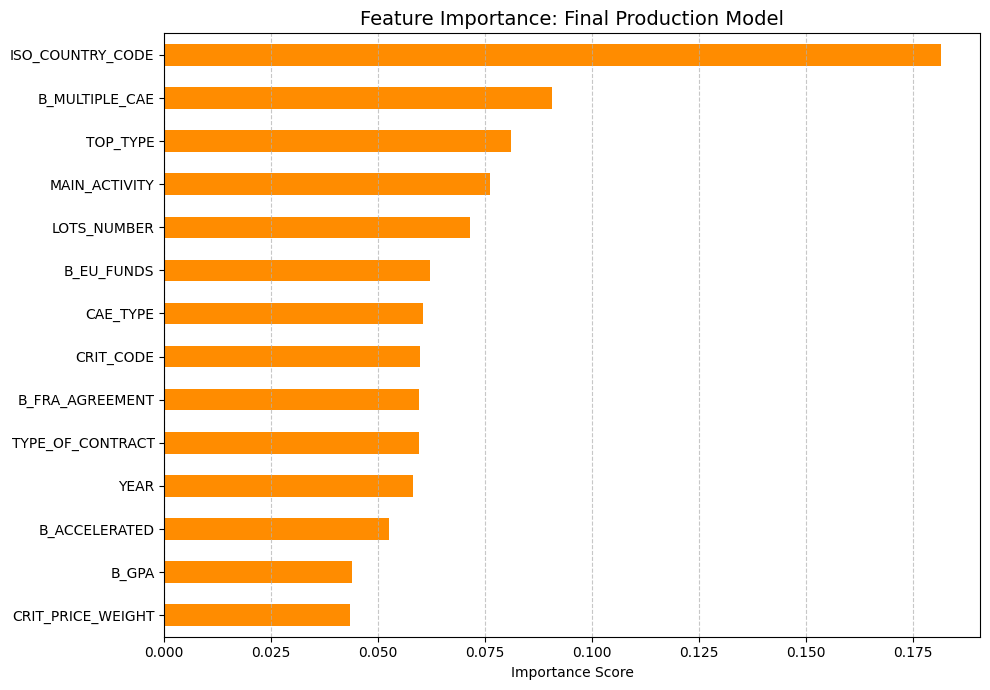


=== Top Feature Ranking ===
ISO_COUNTRY_CODE     0.181499
B_MULTIPLE_CAE       0.090635
TOP_TYPE             0.081024
MAIN_ACTIVITY        0.076094
LOTS_NUMBER          0.071521
B_EU_FUNDS           0.062201
CAE_TYPE             0.060405
CRIT_CODE            0.059781
B_FRA_AGREEMENT      0.059566
TYPE_OF_CONTRACT     0.059475
YEAR                 0.058025
B_ACCELERATED        0.052570
B_GPA                0.043771
CRIT_PRICE_WEIGHT    0.043434
dtype: float32


In [35]:
## Cell 5

import pickle
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

print("Training the Final Production Model with Optimal Optuna Parameters...")

# 1. Initialize the model with the best parameters from your 50-cycle Optuna run
best_params = {
    'n_estimators': 515,
    'max_depth': 12,
    'learning_rate': 0.16622541758650666,
    'subsample': 0.8542893599077008,
    'colsample_bytree': 0.9515841116897474,
    'min_child_weight': 5,
    'gamma': 0.22951520720861468,
    'reg_alpha': 0.9945860327755901,
    'reg_lambda': 2.0816118531227312,
    
    # Fixed production settings
    'tree_method': 'hist',
    'enable_categorical': True,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 30
}

final_model = XGBClassifier(**best_params)

# 2. Train the model (Validation set is used for early stopping to prevent any overfitting)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50 
)

# 3. Final Evaluation on the purely unseen Test Set
print("\nPerforming Final Evaluation on Test Set...")
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_test_prob)
test_acc = accuracy_score(y_test, y_test_pred)

print("\n" + "="*40)
print("=== FINAL LEAK-FREE TEST RESULTS ===")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print(f"Test Accuracy: {test_acc*100:.1f}%")
print("="*40)
print(classification_report(y_test, y_test_pred, target_names=['Not Awarded', 'Awarded']))

# 4. Save the Production Model
model_filename = 'final_production_radar_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(final_model, f)
print(f"\n✅ Production model successfully saved as '{model_filename}'")

# 5. Visualize Feature Importance
feat_imp = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='darkorange')
plt.title('Feature Importance: Final Production Model', fontsize=14)
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display ranking
print("\n=== Top Feature Ranking ===")
print(feat_imp.sort_values(ascending=False))

In [40]:
## Cell 6

import pandas as pd
import numpy as np

print("Testing the model with one Awarded and one Non-Awarded tender...\n")

# 1. Sample one of each class from the existing X_test/y_test
# Using a set random_state so you get the same specific rows each time you run it
awarded_idx = y_test[y_test == 1].sample(1, random_state=42).index
not_awarded_idx = y_test[y_test == 0].sample(1, random_state=99).index

test_samples = X_test.loc[awarded_idx.append(not_awarded_idx)]
actual_labels = ['Awarded (1)', 'Not Awarded (0)']

# 2. Get predictions and exact probabilities
predicted_classes = final_model.predict(test_samples)
probabilities = final_model.predict_proba(test_samples)

# 3. Display the results clearly
for i, idx in enumerate(test_samples.index):
    print(f"=== Test Case {i+1} : Actual Result = {actual_labels[i]} ===")
    
    # Display a snapshot of what the model is looking at
    print("Snapshot of Input Features:")
    snapshot = test_samples.loc[idx, ['TOP_TYPE', 'TYPE_OF_CONTRACT', 'MAIN_ACTIVITY', 'ISO_COUNTRY_CODE', 'LOTS_NUMBER']]
    print(snapshot.to_string())
    
    # Extract probability of class 1 (Awarded)
    prob_awarded = probabilities[i][1]
    
    # Determine the label based on the standard 0.5 threshold
    pred_label = "Awarded (1)" if predicted_classes[i] == 1 else "Not Awarded (0)"
    
    # Confidence is simply how certain the model is of its chosen class 
    # (e.g., a 0.10 prob of award means it is 90% confident it will NOT be awarded)
    confidence = max(prob_awarded, 1 - prob_awarded) * 100
    
    print("\nModel Output:")
    print(f"  Predicted Class              : {pred_label}")
    if predicted_classes[i] == y_test.loc[idx]:
        print("  Status                       : ✅ CORRECT")
    else:
        print("  Status                       : ❌ INCORRECT")
        
    print(f"  Probability of being Awarded : {prob_awarded * 100:.2f}%")
    print(f"  Confidence Score             : {confidence:.2f}%")
    print("=" * 55 + "\n")

Testing the model with one Awarded and one Non-Awarded tender...

=== Test Case 1 : Actual Result = Awarded (1) ===
Snapshot of Input Features:
TOP_TYPE                                OPE
TYPE_OF_CONTRACT                          W
MAIN_ACTIVITY       General public\services
ISO_COUNTRY_CODE                         DK
LOTS_NUMBER                             7.0

Model Output:
  Predicted Class              : Not Awarded (0)
  Status                       : ❌ INCORRECT
  Probability of being Awarded : 49.12%
  Confidence Score             : 50.88%

=== Test Case 2 : Actual Result = Not Awarded (0) ===
Snapshot of Input Features:
TOP_TYPE                                RES
TYPE_OF_CONTRACT                          S
MAIN_ACTIVITY       General public\services
ISO_COUNTRY_CODE                         NL
LOTS_NUMBER                             1.0

Model Output:
  Predicted Class              : Awarded (1)
  Status                       : ❌ INCORRECT
  Probability of being Awarded : 75.91%

In [41]:
## Cell 7

import pandas as pd
import numpy as np
import pickle

print("Loading the saved production model...")
model_filename = '../raw_data/final_production_radar_model.pkl'

with open(model_filename, 'rb') as f:
    loaded_model = pickle.load(f)

print("✅ Model loaded successfully!\n")
print("Testing the loaded model with random Awarded and Non-Awarded tenders...\n")

# 1. Sample one of each class from the existing X_test/y_test
# Removed 'random_state' so it picks completely new rows every time you run this cell!
awarded_idx = y_test[y_test == 1].sample(1).index
not_awarded_idx = y_test[y_test == 0].sample(1).index

test_samples = X_test.loc[awarded_idx.append(not_awarded_idx)]
actual_labels = ['Awarded (1)', 'Not Awarded (0)']

# 2. Get predictions and exact probabilities using the LOADED model
predicted_classes = loaded_model.predict(test_samples)
probabilities = loaded_model.predict_proba(test_samples)

# 3. Display the results clearly
for i, idx in enumerate(test_samples.index):
    print(f"=== Test Case {i+1} : Actual Result = {actual_labels[i]} ===")
    
    # Display a snapshot of what the model is looking at
    print("Snapshot of Input Features:")
    snapshot = test_samples.loc[idx, ['TOP_TYPE', 'TYPE_OF_CONTRACT', 'MAIN_ACTIVITY', 'ISO_COUNTRY_CODE', 'LOTS_NUMBER']]
    print(snapshot.to_string())
    
    # Extract probability of class 1 (Awarded)
    prob_awarded = probabilities[i][1]
    
    # Determine the label based on the standard 0.5 threshold
    pred_label = "Awarded (1)" if predicted_classes[i] == 1 else "Not Awarded (0)"
    
    # Confidence is simply how certain the model is of its chosen class 
    confidence = max(prob_awarded, 1 - prob_awarded) * 100
    
    print("\nModel Output:")
    print(f"  Predicted Class              : {pred_label}")
    if predicted_classes[i] == y_test.loc[idx]:
        print("  Status                       : ✅ CORRECT")
    else:
        print("  Status                       : ❌ INCORRECT")
        
    print(f"  Probability of being Awarded : {prob_awarded * 100:.2f}%")
    print(f"  Confidence Score             : {confidence:.2f}%")
    print("=" * 55 + "\n")

Loading the saved production model...
✅ Model loaded successfully!

Testing the loaded model with random Awarded and Non-Awarded tenders...

=== Test Case 1 : Actual Result = Awarded (1) ===
Snapshot of Input Features:
TOP_TYPE                                OPE
TYPE_OF_CONTRACT                          S
MAIN_ACTIVITY       General public\services
ISO_COUNTRY_CODE                         FI
LOTS_NUMBER                             3.0

Model Output:
  Predicted Class              : Not Awarded (0)
  Status                       : ❌ INCORRECT
  Probability of being Awarded : 47.06%
  Confidence Score             : 52.94%

=== Test Case 2 : Actual Result = Not Awarded (0) ===
Snapshot of Input Features:
TOP_TYPE               OPE
TYPE_OF_CONTRACT         U
MAIN_ACTIVITY       Health
ISO_COUNTRY_CODE        LT
LOTS_NUMBER           43.0

Model Output:
  Predicted Class              : Not Awarded (0)
  Status                       : ✅ CORRECT
  Probability of being Awarded : 41.18%
  Confi

Initializing SHAP TreeExplainer (This might take a few seconds)...

=== SHAP Waterfall Plot: Test Case 1 ===
Actual: Awarded | Predicted: Awarded (99.19%)


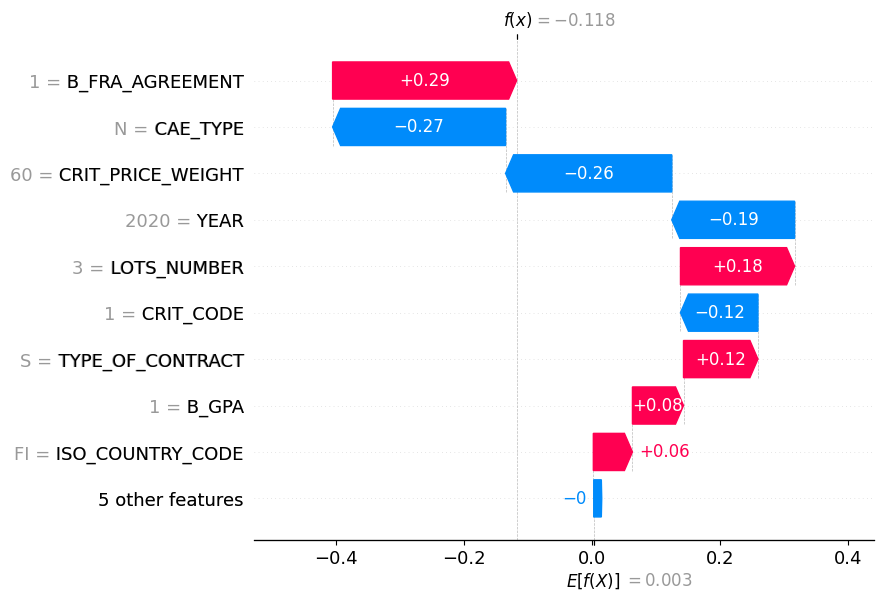


=== SHAP Waterfall Plot: Test Case 2 ===
Actual: Not Awarded | Predicted: Awarded (50.71%)


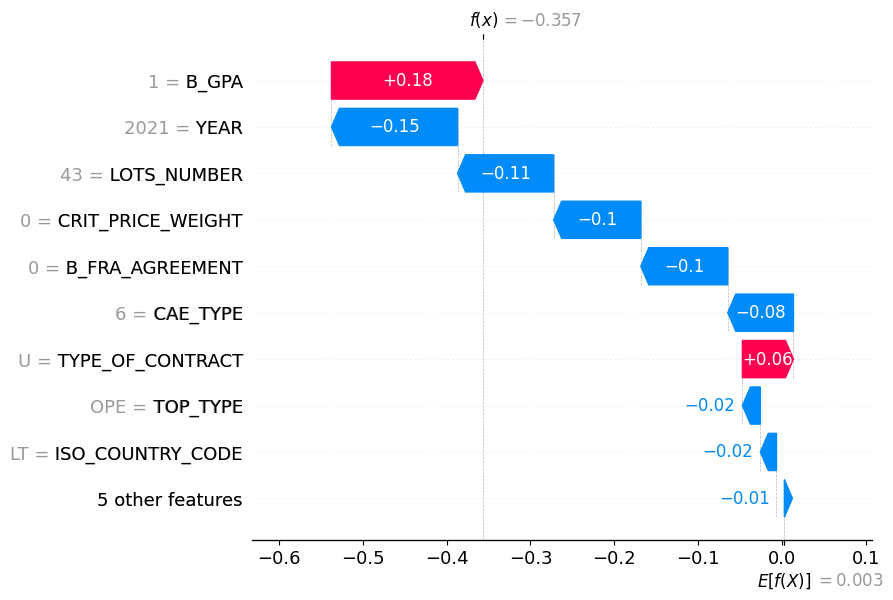

In [42]:
## Cell 8

import shap
import matplotlib.pyplot as plt

print("Initializing SHAP TreeExplainer (This might take a few seconds)...")
# SHAP's TreeExplainer is highly optimized for XGBoost
explainer = shap.TreeExplainer(loaded_model)

# Calculate SHAP values for our two specific test samples
shap_values = explainer(test_samples)

print("\n" + "="*60)
print("=== SHAP Waterfall Plot: Test Case 1 ===")
print("Actual: Awarded | Predicted: Awarded (99.19%)")
print("="*60)
# This plot shows how we start from the base expected value and arrive at the final prediction
shap.plots.waterfall(shap_values[0])

print("\n" + "="*60)
print("=== SHAP Waterfall Plot: Test Case 2 ===")
print("Actual: Not Awarded | Predicted: Awarded (50.71%)")
print("="*60)
shap.plots.waterfall(shap_values[1])